# **SHETH L.U.J. & SIR M.V. COLLEGE**
**Shreeraj Desai | T075**
## **Practical No. 8**

**Aim** :- K-Means Clustering
*  Apply the K-Means algorithm to group similar data points into clusters.
*  Determine the optimal number of clusters using elbow method or silhouette analysis.
*  Visualize the clustering results and analyze the cluster characteristics.

# Import libraries

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

# Load the Dataset

In [20]:
try:
    df = pd.read_csv('Datasets/Mall_Customers.csv')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: 'Mall_Customers.csv' not found. Please ensure the file is in the correct directory.")
    df = pd.DataFrame() # Create empty dataframe to avoid errors

if not df.empty:
    df.head()

Dataset loaded successfully.


# Exploratory Data Analysis

In [21]:
if not df.empty:
    print("Shape of the dataset:", df.shape)
    print("\n--- Descriptive Statistics ---")
    print(df.describe())
    print("\n--- Data Info ---")
    df.info()
    print("\n--- Null Values ---")
    print(df.isnull().sum())

Shape of the dataset: (200, 5)

--- Descriptive Statistics ---
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.250000   49.000000           78.000000               73.000000
max    200.000000   70.000000          137.000000               99.000000

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null   

# Data Visualization

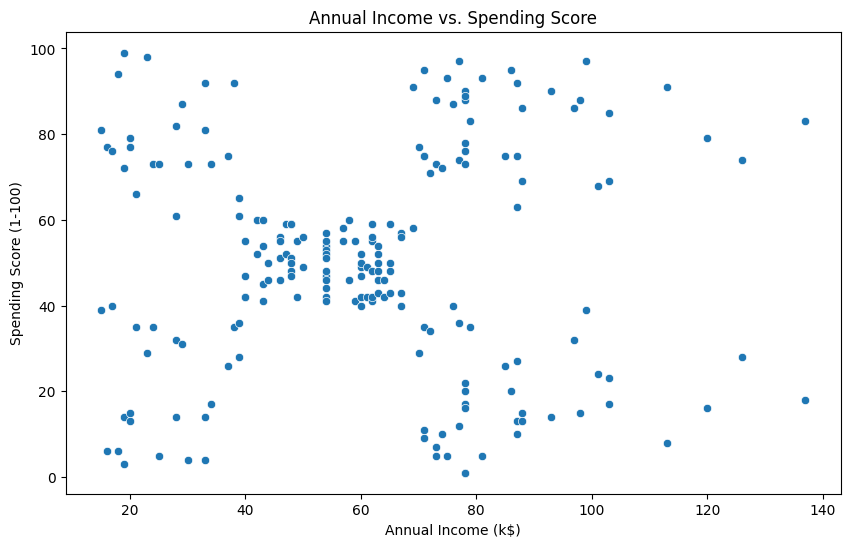

In [22]:
# Scatter plot for the features we will use for clustering
if not df.empty:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', data=df)
    plt.title('Annual Income vs. Spending Score')
    plt.show()

# Feature Selection for Clustering

In [23]:
# We will cluster based on 'Annual Income (k$)' and 'Spending Score (1-100)'
# We select these columns by their index location (iloc)
if not df.empty:
    X = df.iloc[:, [3, 4]].values

# Finding the optimal number of clusters using the Elbow Method

In [24]:
# WCSS = Within Cluster Sum of Squares
if not df.empty:
    wcss = []
    for i in range(1, 11):
        kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
        kmeans.fit(X)
        wcss.append(kmeans.inertia_) # inertia_ is the WCSS value

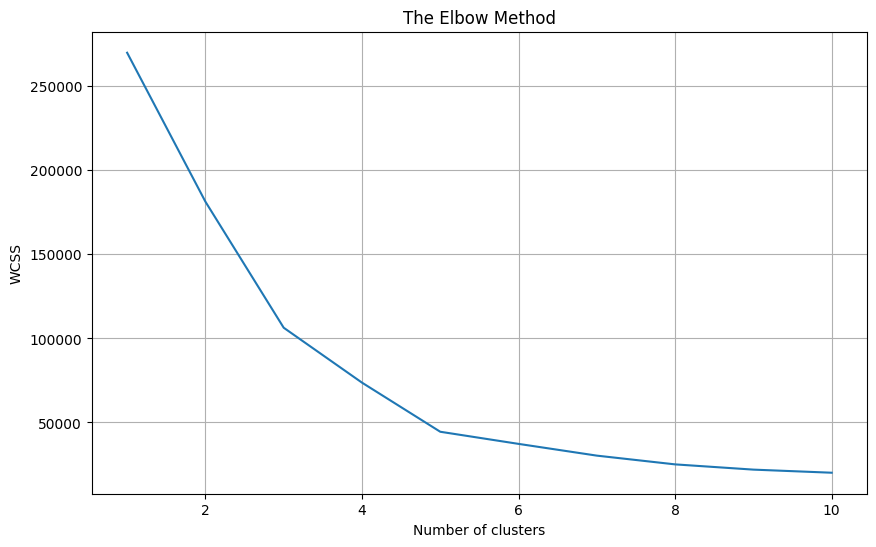

In [25]:
# Plot the Elbow graph
if not df.empty:
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, 11), wcss)
    plt.title('The Elbow Method')
    plt.xlabel('Number of clusters')
    plt.ylabel('WCSS')
    plt.grid(True)
    plt.show()

Based on the elbow plot, the optimal number of clusters (k) is clearly **5**. The 'elbow' or point of inflection where the rate of decrease in WCSS slows down significantly is at k=5.

# Training the K-Means model

In [26]:
# Applying KMeans to the dataset with the optimal number of clusters (k=5)
if not df.empty:
    kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
    y_kmeans = kmeans.fit_predict(X)

# Visualizing the clusters

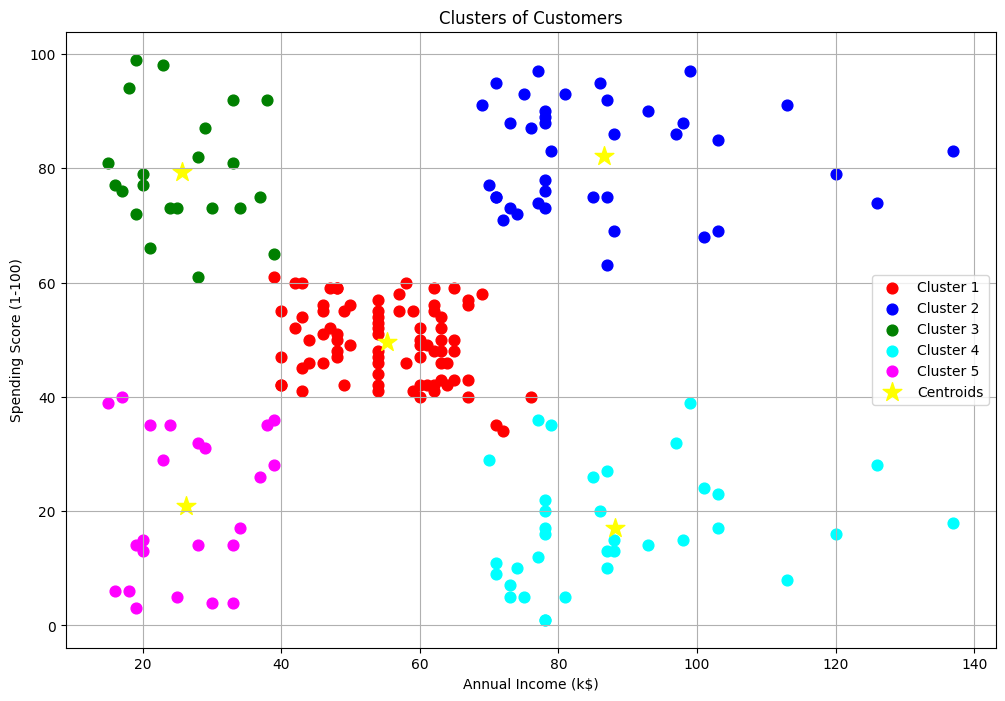

In [ ]:
if not df.empty:
    plt.figure(figsize=(12, 8))
    
    # Scatter plot for each of the 5 clusters
    plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s=60, c='red', label='Cluster 1')
    plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s=60, c='blue', label='Cluster 2')
    plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s=60, c='green', label='Cluster 3')
    plt.scatter(X[y_kmeans == 3, 0], X[y_kmeans == 3, 1], s=60, c='cyan', label='Cluster 4')
    plt.scatter(X[y_kmeans == 4, 0], X[y_kmeans == 4, 1], s=60, c='magenta', label='Cluster 5')

    # Plot the centroids
    plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=200, c='yellow', marker='*', label='Centroids')

    plt.title('Clusters of Customers')
    plt.xlabel('Annual Income (k$)')
    plt.ylabel('Spending Score (1-100)')
    plt.legend()
    plt.grid(True)
    plt.show()